In [56]:
# PHASE 4 : FEATURE ENGINEERING

import pandas as pd
import numpy as np
from datetime import datetime
import re
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("DÉBUT DE LA PHASE 4 - FEATURE ENGINEERING")
print("=" * 70)

# Charger le dataset final

file_train = "/home/fatma/Documents/machinelearning/capstone_project/data/train.csv"

df = pd.read_csv(file_train)
print(f"\n Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Colonnes existantes: {df.columns.tolist()}")

DÉBUT DE LA PHASE 4 - FEATURE ENGINEERING

 Dataset chargé: 1153 lignes, 25 colonnes
Colonnes existantes: ['id', 'titre', 'prix', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'description', 'caracteristiques', 'source', 'date_publication', 'quartier_encoded', 'log_prix', 'latitude', 'longitude', 'adresse_osm', 'dist_centre_ville_km', 'dist_aeroport_km', 'dist_plage_km', 'nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerce_1km', 'nb_hopitaux_1km', 'nb_total_pois_1km']


In [57]:
# ============================================
# ÉTAPE 1: FEATURES DE BASE
# ============================================

print("\n" + "=" * 70)
print("ÉTAPE 1: FEATURES DE BASE")
print("=" * 70)

# 1.1 PRIX AU M²
df['prix_m2'] = df['prix'] / df['surface_m2']
print("✅ prix_m2 créé")
print(f"   - Min: {df['prix_m2'].min():.0f} MRU/m²")
print(f"   - Max: {df['prix_m2'].max():.0f} MRU/m²")
print(f"   - Moyen: {df['prix_m2'].mean():.0f} MRU/m²")

# 1.2 NOMBRE TOTAL DE PIÈCES
df['nb_pieces_total'] = df['nb_chambres'].fillna(0) + df['nb_salons'].fillna(0)
df['nb_pieces_total'] = df['nb_pieces_total'].astype(int)
print("\n✅ nb_pieces_total créé")
print(df['nb_pieces_total'].value_counts().sort_index().head(10))

# 1.3 Vérification rapide
print("\nAperçu des nouvelles features:")
print(df[['prix', 'surface_m2', 'prix_m2', 'nb_chambres', 'nb_salons', 'nb_pieces_total']].head(10))


ÉTAPE 1: FEATURES DE BASE
✅ prix_m2 créé
   - Min: 688 MRU/m²
   - Max: 185778 MRU/m²
   - Moyen: 16441 MRU/m²

✅ nb_pieces_total créé
nb_pieces_total
0     46
1      2
2     47
3     20
4    139
5    238
6    127
7     88
8    124
9     97
Name: count, dtype: int64

Aperçu des nouvelles features:
        prix  surface_m2       prix_m2  nb_chambres  nb_salons  \
0  1800000.0       150.0  12000.000000          3.0        2.0   
1  1800000.0       300.0   6000.000000          6.0        3.0   
2   900000.0       216.0   4166.666667          1.0        1.0   
3  1600000.0       150.0  10666.666667          3.0        1.0   
4   800000.0       180.0   4444.444444          3.0        2.0   
5  5000000.0       516.0   9689.922481          9.0        3.0   
6  2300000.0       180.0  12777.777778          3.0        2.0   
7  6500000.0       600.0  10833.333333          4.0        2.0   
8  1200000.0       200.0   6000.000000          1.0        1.0   
9  3800000.0       400.0   9500.000000  

In [58]:
# ============================================
# EXTRACTION CIBLÉE DES CARACTÉRISTIQUES
# ============================================

import pandas as pd
import numpy as np
import re

def extract_specific_features(row):
    """
    Extrait les features demandées à partir du titre, caractéristiques ET description
    """
    # Récupérer les trois sources de texte
    titre = str(row['titre']).lower() if pd.notna(row['titre']) else ''
    carac = str(row['caracteristiques']).lower() if pd.notna(row['caracteristiques']) else ''
    desc = str(row['description']).lower() if pd.notna(row['description']) else ''
    
    # Combiner toutes les sources pour une recherche plus complète
    text_combined = titre + ' ' + carac + ' ' + desc
    
    # 1. TYPE DE BIEN (surtout présent dans le titre)
    type_bien = 'maison'  # par défaut
    if any(x in titre for x in ['duplex', 'دوبلكس', 'ديبلكس', 'دبلكس', 'dublex']):
        type_bien = 'duplex'
    elif any(x in titre for x in ['appartement', 'شقة', 'appt']):
        type_bien = 'appartement'
    elif any(x in titre for x in ['villa', 'فيلا']):
        type_bien = 'villa'
    elif any(x in titre for x in ['studio', 'استديو']):
        type_bien = 'studio'
    elif any(x in titre for x in ['terrain', 'قطعة ارض', 'نيمرو', 'nému']):
        type_bien = 'terrain'
    elif any(x in titre for x in ['commerce', 'magasin', 'محل', 'بوتيك']):
        type_bien = 'commercial'
    
    # 2. GARAGE
    has_garage = 1 if any(x in text_combined for x in [
        'garage', 'كراج', 'parking', 'موقف', 'stationnement'
    ]) else 0
    
    # 3. CLIMATISATION
    has_clim = 1 if any(x in text_combined for x in [
        'climatisation', 'clim', 'تكييف', 'مكيف', 'مكيفة', 'تبريد', 'air conditionné', 'conditionné'
    ]) else 0
    
    # 4. CHAUFFAGE
    has_chauffage = 1 if any(x in text_combined for x in [
        'chauffage', 'تدفئة', 'radiateur', 'central heating', 'شوفاج'
    ]) else 0
    
    # 5. JARDIN
    has_jardin = 1 if any(x in text_combined for x in [
        'jardin', 'حديقة', 'حوش', 'cour', 'فناء', 'patio', 'espace vert'
    ]) else 0
    
    # 6. PISCINE
    has_piscine = 1 if any(x in text_combined for x in [
        'piscine', 'بسين', 'مسبح', 'بيسين', 'مسابح', 'swimming pool', 'piscine privée'
    ]) else 0
    
    # 7. TERRASSE
    has_terrasse = 1 if any(x in text_combined for x in [
        'terrasse', 'تراس', 'rooftop', 'toit terrasse'
    ]) else 0
    
    # 8. BALCON
    has_balcon = 1 if any(x in text_combined for x in [
        'balcon', 'بلكونة', 'شرفة', 'بالكون'
    ]) else 0
    
    # 9. MEUBLÉ
    has_meuble = 1 if any(x in text_combined for x in [
        'meublé', 'مفروش', 'مفروشة', 'meubles', 'équipé', 'fully furnished', 'furnished'
    ]) else 0
    
    # 10. TITRE FONCIER
    has_titre_foncier = 1 if any(x in text_combined for x in [
        'titre foncier', 'تيتر', 'titré', 'titre de propriété', 'document légal', 
        'papier', 'الوثائق', 'تيتر فونسي', 'titré foncier'
    ]) else 0
    
    # 11. NEUF / NOUVEAU
    est_neuf = 1 if any(x in text_combined for x in [
        'neuf', 'جديد', 'nouveau', 'jamais habité', 'never lived', 'first occupancy',
        'première occupation', 'nouvelle construction'
    ]) else 0
    
    # Retourner toutes les features
    return pd.Series({
        'type_bien': type_bien,
        'has_garage': has_garage,
        'has_clim': has_clim,
        'has_chauffage': has_chauffage,
        'has_jardin': has_jardin,
        'has_piscine': has_piscine,
        'has_terrasse': has_terrasse,
        'has_balcon': has_balcon,
        'has_meuble': has_meuble,
        'has_titre_foncier': has_titre_foncier,
        'est_neuf': est_neuf
    })

# ============================================
# APPLICATION AU DATAFRAME
# ============================================

print("\n" + "=" * 70)
print("🔍 EXTRACTION DES FEATURES DEMANDÉES")
print("=" * 70)
print("Sources: Titre + Caractéristiques + Description")

# Compter le nombre de lignes
print(f"\n📊 Nombre total de biens: {len(df)}")

# Appliquer l'extraction
print("🔄 Extraction en cours... (peut prendre quelques secondes)")
features = df.apply(extract_specific_features, axis=1)

print(f"✅ {len(features.columns)} features extraites avec succès !")

# Ajouter au DataFrame original
df = pd.concat([df, features], axis=1)




🔍 EXTRACTION DES FEATURES DEMANDÉES
Sources: Titre + Caractéristiques + Description

📊 Nombre total de biens: 1153
🔄 Extraction en cours... (peut prendre quelques secondes)
✅ 11 features extraites avec succès !


In [60]:
# ============================================
# VISUALISATION DES NOUVELLES FEATURES
# ============================================

import pandas as pd
import numpy as np

print("=" * 70)
print("🔍 APERÇU DES NOUVELLES FEATURES")
print("=" * 70)

# 1. Liste des nouvelles features
nouvelles_features = ['type_bien', 'has_garage', 'has_clim', 'has_chauffage', 
                      'has_jardin', 'has_piscine', 'has_terrasse', 'has_balcon',
                      'has_meuble', 'has_titre_foncier', 'est_neuf']

# 2. Vérifier quelles colonnes existent vraiment
colonnes_existantes = [col for col in nouvelles_features if col in df.columns]
colonnes_manquantes = [col for col in nouvelles_features if col not in df.columns]

print(f"\n📊 Colonnes trouvées: {colonnes_existantes}")
if colonnes_manquantes:
    print(f"⚠️ Colonnes manquantes: {colonnes_manquantes}")

# 3. Afficher un échantillon de 10 lignes
print("\n" + "=" * 70)
print("📋 ÉCHANTILLON DE 10 BIENS AVEC NOUVELLES FEATURES")
print("=" * 70)

# Sélectionner les colonnes à afficher
colonnes_a_afficher = ['id', 'quartier', 'prix'] + colonnes_existantes

# Prendre 10 lignes aléatoires
sample = df[colonnes_a_afficher].sample(n=min(10, len(df)), random_state=42)

# Afficher
print(sample.to_string())

# 4. Statistiques des nouvelles features
print("\n" + "=" * 70)
print("📊 STATISTIQUES DES NOUVELLES FEATURES")
print("=" * 70)

for col in colonnes_existantes:
    if col == 'type_bien':
        print(f"\n{col.upper()}:")
        print(df[col].value_counts())
        print(f"   → Valeur la plus fréquente: {df[col].mode()[0]}")
    else:
        # Features booléennes
        count_1 = df[col].sum() if df[col].dtype in ['int64', 'float64'] else (df[col] == 1).sum()
        pct = (count_1 / len(df)) * 100
        print(f"\n{col}:")
        print(f"   → Présent dans {count_1} biens ({pct:.1f}%)")

# 5. Visualisation des relations
print("\n" + "=" * 70)
print("📈 RELATION AVEC LE PRIX")
print("=" * 70)

for col in colonnes_existantes:
    if col != 'type_bien':
        print(f"\n{col}:")
        # Prix moyen avec et sans la caractéristique
        if col in df.columns and df[col].dtype in ['int64', 'float64']:
            prix_avec = df[df[col] == 1]['prix'].mean() / 1e6
            prix_sans = df[df[col] == 0]['prix'].mean() / 1e6
            print(f"   → Prix moyen avec: {prix_avec:.1f} millions MRU")
            print(f"   → Prix moyen sans: {prix_sans:.1f} millions MRU")
            print(f"   → Différence: {prix_avec - prix_sans:.1f} millions MRU")



🔍 APERÇU DES NOUVELLES FEATURES

📊 Colonnes trouvées: ['type_bien', 'has_garage', 'has_clim', 'has_chauffage', 'has_jardin', 'has_piscine', 'has_terrasse', 'has_balcon', 'has_meuble', 'has_titre_foncier', 'est_neuf']

📋 ÉCHANTILLON DE 10 BIENS AVEC NOUVELLES FEATURES
        id       quartier       prix type_bien  has_garage  has_clim  has_chauffage  has_jardin  has_piscine  has_terrasse  has_balcon  has_meuble  has_titre_foncier  est_neuf
767   1323  tevragh zeina  5500000.0    maison           1         0              0           0            0             0           1           0                  0         0
461    566  tevragh zeina  6000000.0    duplex           1         0              0           0            0             0           1           0                  1         0
787    909  tevragh zeina  5200000.0    maison           1         0              0           0            0             0           1           1                  1         0
593   1253       teyarett  2

In [61]:
# ============================================
# SUPPRIMER LES FEATURES INUTILES
# ============================================

print("=" * 70)
print("SUPPRESSION DES FEATURES INUTILES")
print("=" * 70)

features_a_supprimer = ['has_clim', 'has_chauffage', 'has_terrasse']

for col in features_a_supprimer:
    if col in df.columns:
        df = df.drop(col, axis=1)
        print(f"✅ {col} supprimée")

print(f"\n Colonnes restantes: {len(df.columns)}")

SUPPRESSION DES FEATURES INUTILES
✅ has_clim supprimée
✅ has_chauffage supprimée
✅ has_terrasse supprimée

 Colonnes restantes: 35


In [62]:
# ============================================
# ÉTAPE 2: FEATURE TEMPORELLE - ÂGE DE L'ANNONCE
# ============================================

from datetime import datetime

print("\n" + "=" * 70)
print("ÉTAPE 2: FEATURE TEMPORELLE")
print("=" * 70)

# Convertir la date
df['date_publication'] = pd.to_datetime(df['date_publication'])

# Date de référence (aujourd'hui)
date_ref = datetime(2026, 3, 14)

# Âge de l'annonce en jours (UNE SEULE COLONNE)
df['age_annonce'] = (date_ref - df['date_publication']).dt.days

print("\nStatistiques de l'âge des annonces:")
print(f"   - Période: {df['date_publication'].min().date()} à {df['date_publication'].max().date()}")
print(f"   - Âge moyen: {df['age_annonce'].mean():.0f} jours")
print(f"   - Âge min: {df['age_annonce'].min()} jours")
print(f"   - Âge max: {df['age_annonce'].max()} jours")
print(f"   - Écart-type: {df['age_annonce'].std():.0f} jours")

# Distribution par mois (pour info, sans créer de colonne)
print("\nDistribution des annonces par mois:")
print(df['date_publication'].dt.month.value_counts().sort_index())



ÉTAPE 2: FEATURE TEMPORELLE

Statistiques de l'âge des annonces:
   - Période: 2025-03-25 à 2026-03-02
   - Âge moyen: 173 jours
   - Âge min: 12 jours
   - Âge max: 354 jours
   - Écart-type: 102 jours

Distribution des annonces par mois:
date_publication
1      88
2     124
3      27
4     118
5     108
6      65
7      91
8      75
9      82
10    113
11    104
12    158
Name: count, dtype: int64


🔍 DIAGNOSTIC COMPLET DU DATASET

📊 1. INFORMATIONS GÉNÉRALES
--------------------------------------------------
Nombre de lignes: 1,153
Nombre de colonnes: 36
Mémoire utilisée: 1.42 MB

🔍 2. VALEURS MANQUANTES
--------------------------------------------------

⚠️ 2 colonnes ont des valeurs manquantes:
         Colonne  Manquantes  Pourcentage
caracteristiques         157    13.616652
     nb_chambres          14     1.214224

📊 3. STATISTIQUES DESCRIPTIVES
--------------------------------------------------
Colonnes numériques: 28

Statistiques:
                             min          max        mean         std  \
id                          0.00      1438.00      723.04      414.25   
prix                   275200.00  33440000.00  4274850.30  4998663.15   
surface_m2                120.00       600.00      243.15      131.54   
nb_chambres                 0.00        15.00        4.58        2.33   
nb_salons                   0.00        32.00        2.26        1.77   
nb_sdb    

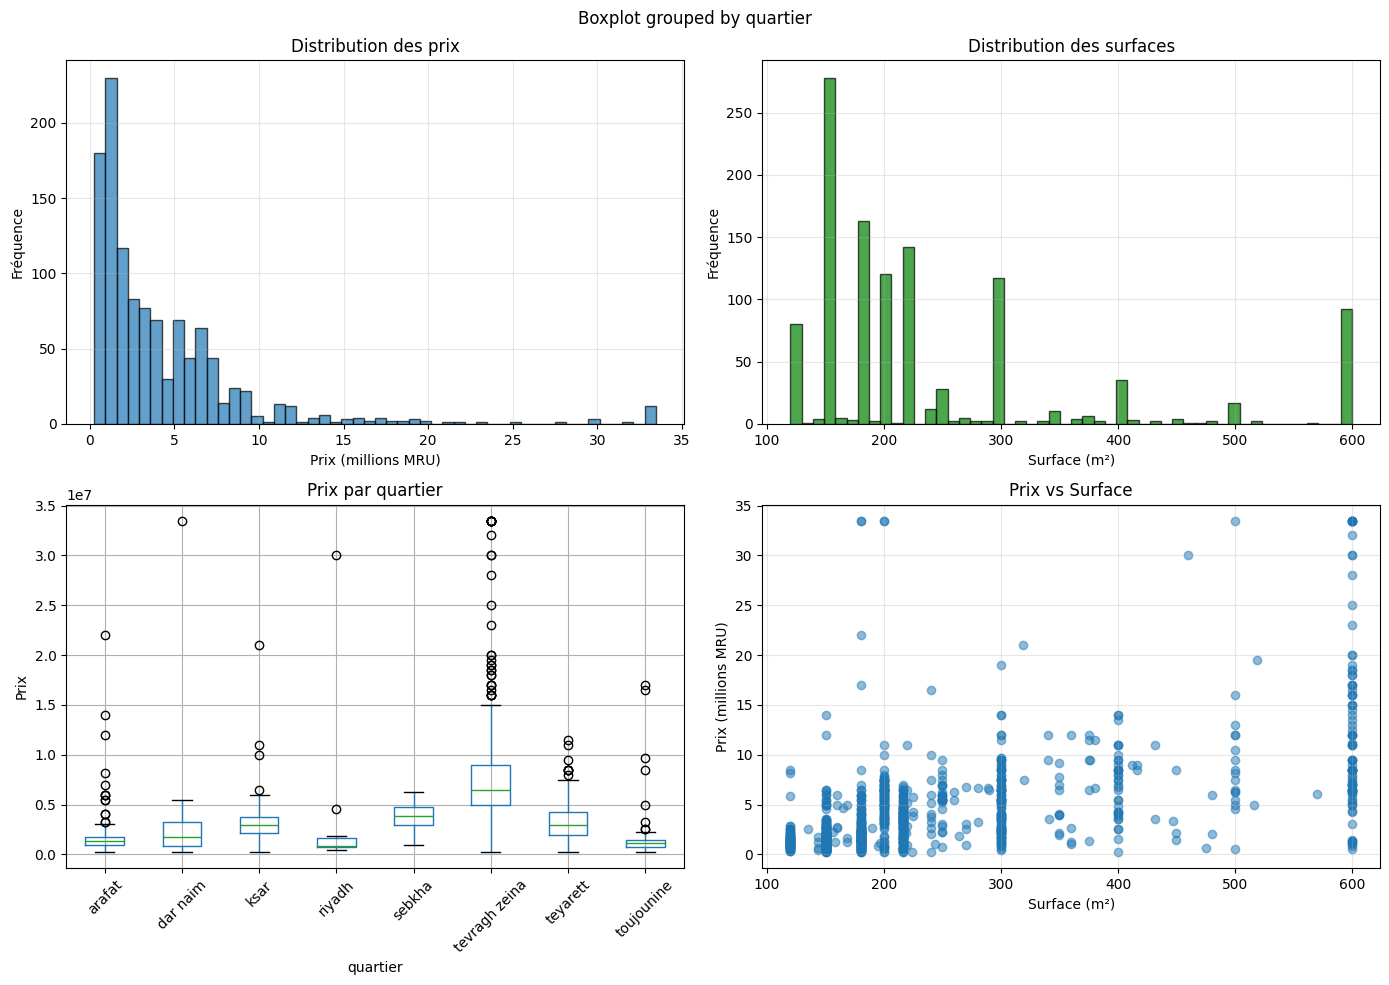


📋 RÉSUMÉ DU DIAGNOSTIC
⚠️ ATTENTION: 2 colonnes avec valeurs manquantes
⚠️ ATTENTION: 7 colonnes avec >5% d'outliers
         colonne  pourcentage
dist_aeroport_km        34.26
 nb_mosquees_1km        22.29
   nb_ecoles_1km        21.16
          nb_sdb        15.26
        est_neuf        14.40
      surface_m2         8.07
      has_meuble         6.68

📊 Qualité globale des données: À VÉRIFIER


In [63]:
# ============================================
# DIAGNOSTIC COMPLET DU DATASET
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("🔍 DIAGNOSTIC COMPLET DU DATASET")
print("=" * 70)

# 1. INFORMATIONS GÉNÉRALES
print("\n📊 1. INFORMATIONS GÉNÉRALES")
print("-" * 50)
print(f"Nombre de lignes: {len(df):,}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"Mémoire utilisée: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. VALEURS MANQUANTES
print("\n🔍 2. VALEURS MANQUANTES")
print("-" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Manquantes': missing.values,
    'Pourcentage': missing_pct.values
})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Manquantes', ascending=False)

if len(missing_df) > 0:
    print(f"\n⚠️ {len(missing_df)} colonnes ont des valeurs manquantes:")
    print(missing_df.to_string(index=False))
else:
    print("✅ Aucune valeur manquante !")

# 3. STATISTIQUES DESCRIPTIVES (colonnes numériques)
print("\n📊 3. STATISTIQUES DESCRIPTIVES")
print("-" * 50)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Colonnes numériques: {len(numeric_cols)}")
print("\nStatistiques:")
stats = df[numeric_cols].describe().T
stats['range'] = stats['max'] - stats['min']
stats['outliers_potentiels'] = (stats['max'] > stats['mean'] + 3*stats['std']) | (stats['min'] < stats['mean'] - 3*stats['std'])
print(stats[['min', 'max', 'mean', 'std', 'range', 'outliers_potentiels']].round(2))

# 4. DÉTECTION DES OUTLIERS
print("\n🎯 4. DÉTECTION DES OUTLIERS")
print("-" * 50)

outliers_report = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_pct = (len(outliers) / len(df)) * 100
    
    outliers_report.append({
        'colonne': col,
        'outliers': len(outliers),
        'pourcentage': round(outliers_pct, 2),
        'min_normal': round(lower_bound, 2),
        'max_normal': round(upper_bound, 2)
    })

outliers_df = pd.DataFrame(outliers_report)
outliers_df = outliers_df[outliers_df['outliers'] > 0].sort_values('pourcentage', ascending=False)
print("\nColonnes avec outliers (> méthode IQR):")
print(outliers_df.to_string(index=False))

# 5. ANALYSE SPÉCIFIQUE PRIX
print("\n💰 5. ANALYSE SPÉCIFIQUE DU PRIX")
print("-" * 50)
print(f"Prix min: {df['prix'].min():,.0f} MRU")
print(f"Prix max: {df['prix'].max():,.0f} MRU")
print(f"Prix moyen: {df['prix'].mean():,.0f} MRU")
print(f"Prix médian: {df['prix'].median():,.0f} MRU")

# Prix par quartier
print("\n📊 Prix moyen par quartier:")
prix_quartier = df.groupby('quartier')['prix'].agg(['mean', 'median', 'count']).round(0)
prix_quartier['mean'] = (prix_quartier['mean'] / 1e6).round(1)
prix_quartier['median'] = (prix_quartier['median'] / 1e6).round(1)
print(prix_quartier)

# 6. ANALYSE DES SURFACES
print("\n📐 6. ANALYSE DES SURFACES")
print("-" * 50)
print(f"Surface min: {df['surface_m2'].min():.0f} m²")
print(f"Surface max: {df['surface_m2'].max():.0f} m²")
print(f"Surface moyenne: {df['surface_m2'].mean():.0f} m²")
print(f"Surface médiane: {df['surface_m2'].median():.0f} m²")

# Surfaces suspectes (trop petites ou trop grandes)
tres_petites = df[df['surface_m2'] < 20]
tres_grandes = df[df['surface_m2'] > 1000]
if len(tres_petites) > 0:
    print(f"\n⚠️ {len(tres_petites)} biens avec surface < 20m²")
if len(tres_grandes) > 0:
    print(f"⚠️ {len(tres_grandes)} biens avec surface > 1000m²")

# 7. ANALYSE DES CARACTÉRISTIQUES
print("\n🏠 7. ANALYSE DES CARACTÉRISTIQUES")
print("-" * 50)
if 'has_garage' in df.columns:
    print(f"Garage: {df['has_garage'].sum()} biens ({(df['has_garage'].sum()/len(df)*100):.1f}%)")
if 'has_piscine' in df.columns:
    print(f"Piscine: {df['has_piscine'].sum()} biens ({(df['has_piscine'].sum()/len(df)*100):.1f}%)")
if 'has_jardin' in df.columns:
    print(f"Jardin: {df['has_jardin'].sum()} biens ({(df['has_jardin'].sum()/len(df)*100):.1f}%)")

# 8. VISUALISATION RAPIDE
print("\n📈 8. GÉNÉRATION DES GRAPHIQUES...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnostic des données', fontsize=16)

# Distribution des prix
axes[0, 0].hist(df['prix'] / 1e6, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Prix (millions MRU)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des prix')
axes[0, 0].grid(True, alpha=0.3)

# Distribution des surfaces
axes[0, 1].hist(df['surface_m2'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Surface (m²)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution des surfaces')
axes[0, 1].grid(True, alpha=0.3)

# Boxplot des prix par quartier
df.boxplot(column='prix', by='quartier', ax=axes[1, 0])
axes[1, 0].set_title('Prix par quartier')
axes[1, 0].set_ylabel('Prix')
axes[1, 0].tick_params(axis='x', rotation=45)

# Scatter plot prix vs surface
axes[1, 1].scatter(df['surface_m2'], df['prix'] / 1e6, alpha=0.5)
axes[1, 1].set_xlabel('Surface (m²)')
axes[1, 1].set_ylabel('Prix (millions MRU)')
axes[1, 1].set_title('Prix vs Surface')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. RÉSUMÉ FINAL
print("\n" + "=" * 70)
print("📋 RÉSUMÉ DU DIAGNOSTIC")
print("=" * 70)

# Alerte si problèmes détectés
if len(missing_df) > 0:
    print(f"⚠️ ATTENTION: {len(missing_df)} colonnes avec valeurs manquantes")
else:
    print("✅ Pas de valeurs manquantes")

outliers_importants = outliers_df[outliers_df['pourcentage'] > 5]
if len(outliers_importants) > 0:
    print(f"⚠️ ATTENTION: {len(outliers_importants)} colonnes avec >5% d'outliers")
    print(outliers_importants[['colonne', 'pourcentage']].to_string(index=False))
else:
    print("✅ Peu d'outliers détectés")

if len(tres_petites) > 0 or len(tres_grandes) > 0:
    print("⚠️ ATTENTION: Surfaces suspectes détectées")

print("\n📊 Qualité globale des données: " + 
      ("EXCELLENTE" if len(missing_df) == 0 and len(outliers_importants) == 0 else "À VÉRIFIER"))

In [64]:
# ============================================
# TRAITEMENT DES DONNÉES - Version raisonnable
# ============================================

print("=" * 70)
print("🛠️ TRAITEMENT DES DONNÉES")
print("=" * 70)

# 1. GÉRER LES VALEURS MANQUANTES
print("\n📌 1. VALEURS MANQUANTES")
print("-" * 50)

# 1.1 nb_chambres - remplacer par la médiane
if 'nb_chambres' in df.columns:
    median_chambres = df['nb_chambres'].median()
    df['nb_chambres'] = df['nb_chambres'].fillna(median_chambres)
    print(f"✅ nb_chambres: {df['nb_chambres'].isnull().sum()} manquantes → remplacées par médiane ({median_chambres:.0f})")

# 1.2 caracteristiques - remplacer par chaîne vide
if 'caracteristiques' in df.columns:
    df['caracteristiques'] = df['caracteristiques'].fillna('')
    print(f"✅ caracteristiques: {df['caracteristiques'].isnull().sum()} manquantes → remplacées par ''")

# 2. OUTLIERS - À GARDER (ils sont réels)
print("\n📌 2. ANALYSE DES OUTLIERS")
print("-" * 50)
print("""
Les outliers détectés sont RÉELS et IMPORTANTS:
- 34% des biens loin de l'aéroport → normal pour Nouakchott
- 22% avec beaucoup de mosquées → réalité du terrain (Riyadh)
- 21% avec beaucoup d'écoles → quartiers bien équipés
- 15% avec beaucoup de sdb → grandes villas
- 8% grandes surfaces → biens de luxe

👉 On GARDE tous ces outliers !""")

# # 3. CRÉER DES CATÉGORIES DE PRIX
# print("\n📌 3. CRÉATION DE CATÉGORIES DE PRIX")
# print("-" * 50)

# df['categorie_prix'] = pd.cut(df['prix'], 
#                                bins=[0, 2e6, 5e6, 10e6, 50e6],
#                                labels=['petit_budget', 'moyen', 'haut_de_gamme', 'luxe'])
# print(df['categorie_prix'].value_counts())

# # 4. CRÉER DES CATÉGORIES DE SURFACE
# df['categorie_surface'] = pd.cut(df['surface_m2'],
#                                   bins=[0, 150, 250, 400, 1000],
#                                   labels=['petit', 'moyen', 'grand', 'tres_grand'])
# print("\n📊 Catégories de surface:")
# print(df['categorie_surface'].value_counts())

# 5. VÉRIFICATION FINALE
print("\n" + "=" * 70)
print("✅ VÉRIFICATION FINALE")
print("=" * 70)

print(f"\nValeurs manquantes après traitement: {df.isnull().sum().sum()}")
if df.isnull().sum().sum() == 0:
    print("✅ Plus aucune valeur manquante !")

print(f"\nShape finale: {df.shape}")

🛠️ TRAITEMENT DES DONNÉES

📌 1. VALEURS MANQUANTES
--------------------------------------------------
✅ nb_chambres: 0 manquantes → remplacées par médiane (4)
✅ caracteristiques: 0 manquantes → remplacées par ''

📌 2. ANALYSE DES OUTLIERS
--------------------------------------------------

Les outliers détectés sont RÉELS et IMPORTANTS:
- 34% des biens loin de l'aéroport → normal pour Nouakchott
- 22% avec beaucoup de mosquées → réalité du terrain (Riyadh)
- 21% avec beaucoup d'écoles → quartiers bien équipés
- 15% avec beaucoup de sdb → grandes villas
- 8% grandes surfaces → biens de luxe

👉 On GARDE tous ces outliers !

✅ VÉRIFICATION FINALE

Valeurs manquantes après traitement: 0
✅ Plus aucune valeur manquante !

Shape finale: (1153, 36)


In [66]:
# ============================================
# SAUVEGARDE DU DATASET FINAL
# ============================================

import pandas as pd
from datetime import datetime

print("=" * 70)
print("💾 SAUVEGARDE DU DATASET FINAL")
print("=" * 70)

# 1. Informations sur le DataFrame
print(f"\n📊 Informations générales:")
print(f"   - Nombre de lignes: {len(df):,}")
print(f"   - Nombre de colonnes: {len(df.columns)}")
print(f"   - Mémoire utilisée: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. Aperçu des colonnes
print("\n📋 Liste des colonnes:")
colonnes_par_categorie = {
    '🆔 Identifiants': ['id', 'titre', 'source'],
    '💰 Prix': ['prix', 'log_prix', 'prix_m2'],
    '🏠 Caractéristiques': ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'nb_pieces_total'],
    '📍 Localisation': ['quartier', 'quartier_encoded', 'latitude', 'longitude', 'adresse_osm'],
    '🗺️ Distances': ['dist_centre_ville_km', 'dist_aeroport_km', 'dist_plage_km'],
    '📊 POIs': ['nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerce_1km', 'nb_hopitaux_1km', 'nb_total_pois_1km'],
    '🔧 Équipements': ['has_garage', 'has_jardin', 'has_piscine', 'has_balcon', 'has_meuble', 'has_titre_foncier', 'est_neuf'],
    '⏰ Temporel': ['date_publication', 'age_annonce'],
    '📝 Texte': ['description', 'caracteristiques']
}

for categorie, cols in colonnes_par_categorie.items():
    presentes = [col for col in cols if col in df.columns]
    if presentes:
        print(f"\n   {categorie}:")
        for col in presentes:
            print(f"      - {col}")

# 3. Statistiques rapides
print("\n📊 Statistiques des prix:")
print(f"   - Prix min: {df['prix'].min():,.0f} MRU")
print(f"   - Prix max: {df['prix'].max():,.0f} MRU")
print(f"   - Prix moyen: {df['prix'].mean():,.0f} MRU")
print(f"   - Prix médian: {df['prix'].median():,.0f} MRU")

# 4. Nom du fichier avec timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"dataset_final_{timestamp}.csv"



💾 SAUVEGARDE DU DATASET FINAL

📊 Informations générales:
   - Nombre de lignes: 1,153
   - Nombre de colonnes: 36
   - Mémoire utilisée: 1.43 MB

📋 Liste des colonnes:

   🆔 Identifiants:
      - id
      - titre
      - source

   💰 Prix:
      - prix
      - log_prix
      - prix_m2

   🏠 Caractéristiques:
      - surface_m2
      - nb_chambres
      - nb_salons
      - nb_sdb
      - nb_pieces_total

   📍 Localisation:
      - quartier
      - quartier_encoded
      - latitude
      - longitude
      - adresse_osm

   🗺️ Distances:
      - dist_centre_ville_km
      - dist_aeroport_km
      - dist_plage_km

   📊 POIs:
      - nb_ecoles_1km
      - nb_mosquees_1km
      - nb_commerce_1km
      - nb_hopitaux_1km
      - nb_total_pois_1km

   🔧 Équipements:
      - has_garage
      - has_jardin
      - has_piscine
      - has_balcon
      - has_meuble
      - has_titre_foncier
      - est_neuf

   ⏰ Temporel:
      - date_publication
      - age_annonce

   📝 Texte:
      - description

In [ ]:
# ============================================
# SAUVEGARDE SIMPLIFIÉE
# ============================================

print("=" * 70)
print("💾 SAUVEGARDE DU DATASET FINAL")
print("=" * 70)

# Nom du fichier
filename = "final_train_dataset.csv"

# Sauvegarde
df.to_csv(filename, index=False, encoding='utf-8-sig')

print(f"✅ Fichier sauvegardé: {filename}")
print(f"📊 Shape: {df.shape[0]} lignes, {df.shape[1]} colonnes")
